### Filtering of flames according to attached/detached classification and flame type

#### Importing Libraries

In [6]:
# Sys
import os
import sys
import json
sys.path.append("..")

# Data
import pandas as pd
import numpy as np
import shap
shap.initjs() 
import joblib
import importlib
from src import path
importlib.reload(path)
from src.path import PATH_DATASETV1, PATH_DATA_FLAMELENGTH, PATH_DATA_FLAMELENGTH_NEW, PATH_FLAMELENGTH_FOLDER, PATH_DATA_FLAMELENGTH_MERGED

# Visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, DotProduct, RBF

from sklearn.metrics import mean_squared_error, r2_score

# plotting defaults
%matplotlib inline

In [44]:
def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

#### Merge labels in DatasetV1.xlsx to DatasetFLameComplet.xlsx

In [111]:
df_datasetv1 = pd.read_excel(PATH_DATASETV1)
df_flamelength = pd.read_csv(PATH_DATA_FLAMELENGTH_MERGED)

df_flamelength = df_flamelength[
    np.isclose(df_flamelength['PhiInt_rescaled'], 1.0, atol=1e-4) & (df_flamelength['S1'] == 0)
]
    
print("remaining samples in flamelength:", len(df_flamelength))

# Keys to disambiguate duplicates
merge_keys = ["J", "S1", "S2", "PhiTot", "PhiInt", "u1", "u2"]
num_keys = ["J", "S1", "S2", "PhiTot", "PhiInt", "u1", "u2"]
df_datasetv1[num_keys] = df_datasetv1[num_keys].astype(float).round(3)
df_flamelength[num_keys] = df_flamelength[num_keys].astype(float).round(3)

# Only add these columns from datasetv1
cols_to_add = ["Attache (I/O)", "Groupe", "Type"]

# Remove duplicates from datasetv1, keep first occurrence
df_datasetv1_dedup = df_datasetv1.drop_duplicates(subset=merge_keys, keep="first")

df_merged = pd.merge(
    df_flamelength,
    df_datasetv1_dedup[merge_keys + cols_to_add],
    on=merge_keys,
    how="left",
)


# ---- 1-to-1 validation summary ----
dup_left = df_flamelength.duplicated(subset=merge_keys, keep=False).sum()
dup_right = df_datasetv1_dedup.duplicated(subset=merge_keys, keep=False).sum()
unmatched = df_merged[cols_to_add].isna().all(axis=1).sum()

is_one_to_one = (dup_left == 0) and (dup_right == 0) and (unmatched == 0)

print(f"Duplicate keys in flamelength: {dup_left}")
print(f"Duplicate keys in datasetv1: {dup_right}")
print(f"Unmatched rows after merge: {unmatched}")
print(f"1-to-1 merge achieved: {is_one_to_one}")


# save
output_path = os.path.join(PATH_FLAMELENGTH_FOLDER, "flamelength_with_labels.csv")
df_merged.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

# Save rows from flamelength that did not match (labels are NaN)
unmatched_rows = df_merged[df_merged[cols_to_add].isna().all(axis=1)]
unmatched_path = os.path.join(PATH_FLAMELENGTH_FOLDER, "flamelength_unmatched.csv")
unmatched_rows.to_csv(unmatched_path, index=False)
print(f"Saved unmatched rows to {unmatched_path}")

remaining samples in flamelength: 14
Duplicate keys in flamelength: 0
Duplicate keys in datasetv1: 0
Unmatched rows after merge: 14
1-to-1 merge achieved: False


PermissionError: [Errno 13] Permission denied: 'd:\\Users\\fengchonghui\\Documents\\chong hui\\centralesupelec\\Rozanoff\\rozanoff_2025\\flame_length_pred\\..\\flame_length_pred\\flamelength_with_labels.csv'

#### Processing - removal of non 10kW flames and non-classified flames

In [121]:
df_flamelength_labels = pd.read_csv(os.path.join(PATH_FLAMELENGTH_FOLDER, "flamelength_with_labels.csv"))
print(f"Original samples: {len(df_flamelength_labels)}")

# Remove rows with missing Attache (I/O)
df_filtered = df_flamelength_labels.dropna(subset=['Attache (I/O)'])

# Filter for PWR in range [9.5, 10.5]
df_filtered = df_filtered[
    (df_filtered['PWR'] >= 9.5) & (df_filtered['PWR'] <= 10.5)
]

print(f"Remaining samples: {len(df_filtered)}")

# Keep only attached flames (Attache (I/O) == 1)
df_filtered = df_filtered[df_filtered['Attache (I/O)'] == 1]
    
print("Remaining samples:", len(df_filtered))

# Keep only Type == 1
df_filtered = df_filtered[df_filtered['Type'] =='I']

print(f"Remaining samples: {len(df_filtered)}")

Original samples: 192
Remaining samples: 118
Remaining samples: 74
Remaining samples: 47


#### Visualisation

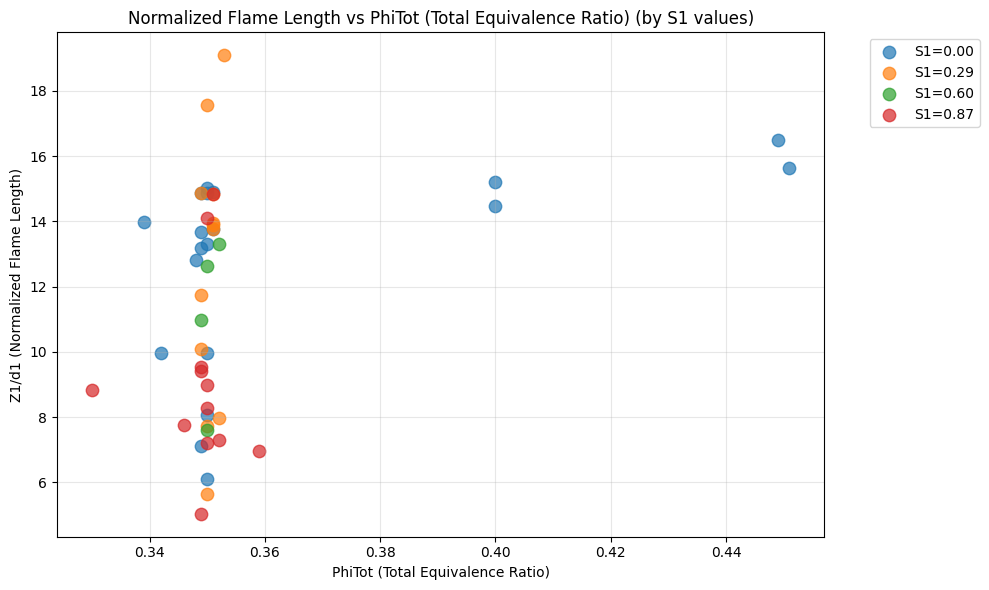

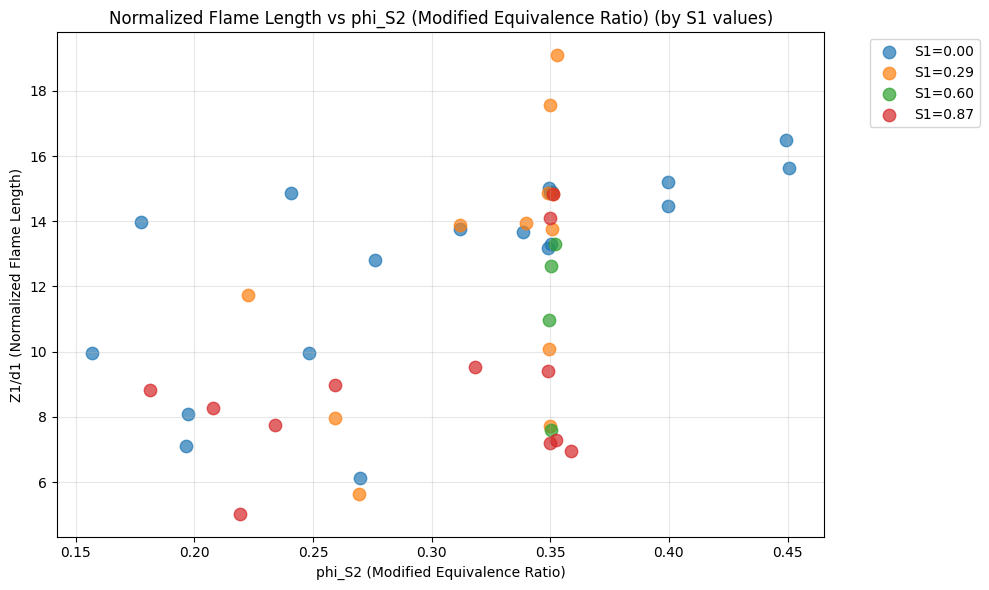

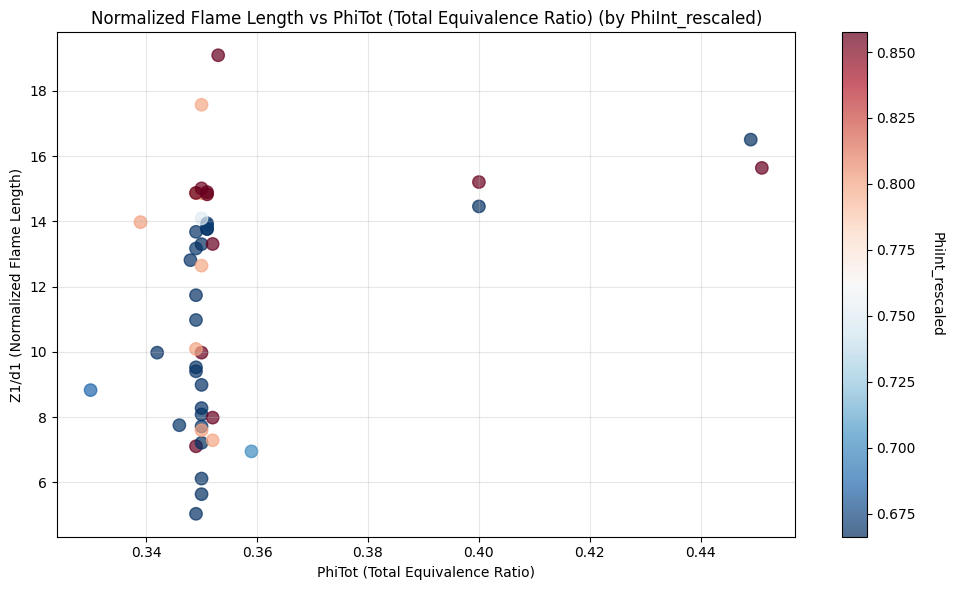

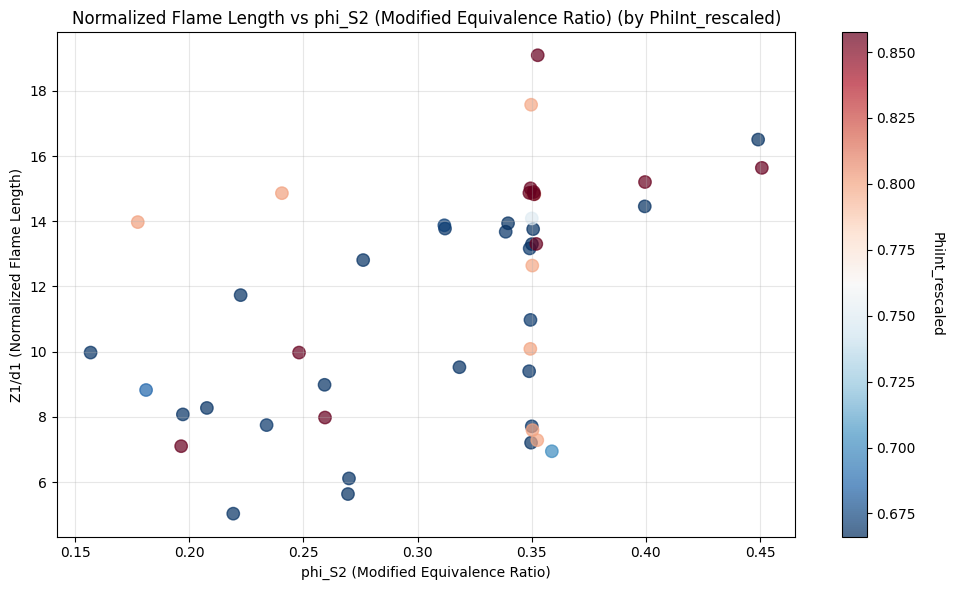

In [122]:
# Get unique S1 values and sort them
s1_values = sorted(df_filtered["S1"].unique())
# Assign distinct colors to each S1 value
distinct_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', 
                   '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78',
                   '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7',
                   '#dbbd22', '#9edae5']
s1_colors = distinct_colors[:len(s1_values)]

# Define plots
plot_configs = [
    # ("1/sqrt_J", "1/sqrt(J)"),
    ("PhiTot", "PhiTot (Total Equivalence Ratio)"),
    ("phi_S2", "phi_S2 (Modified Equivalence Ratio)"),
    # ("S2", "S2"),
]

# Plots colored by S1
for x_col, x_label in plot_configs:
    plt.figure(figsize=(10, 6))
    for i, s1_val in enumerate(s1_values):
        mask = df_filtered["S1"] == s1_val
        plt.scatter(df_filtered[mask][x_col], df_filtered[mask]["Z1/d1"], 
                   label=f'S1={s1_val:.2f}', color=s1_colors[i], alpha=0.7, s=80)
    plt.xlabel(x_label)
    plt.ylabel("Z1/d1 (Normalized Flame Length)")
    plt.title(f"Normalized Flame Length vs {x_label} (by S1 values)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plots colored by PhiInt_rescaled (continuous colormap)
for x_col, x_label in plot_configs:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(df_filtered[x_col], df_filtered["Z1/d1"], 
                         c=df_filtered["PhiInt_rescaled"], cmap='RdBu_r', 
                         alpha=0.7, s=80, vmin=df_filtered["PhiInt_rescaled"].min(), 
                         vmax=df_filtered["PhiInt_rescaled"].max())
    plt.xlabel(x_label)
    plt.ylabel("Z1/d1 (Normalized Flame Length)")
    plt.title(f"Normalized Flame Length vs {x_label} (by PhiInt_rescaled)")
    cbar = plt.colorbar(scatter)
    cbar.set_label("PhiInt_rescaled", rotation=270, labelpad=20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

df = df_filtered.copy()

#### Feature selection

In [123]:
# feature and target selection
features = [
    "PhiInt_rescaled",
    "S1",
    "S2",
    "d1",
    "d2",
    "u1",
    "u2",
    "Chamber_Binary",
    "DeltaU",
    "u2/u1",
    "S2/S1",
    "DeltaS",
]

features = [
    "PhiInt_rescaled",
    "S1",
    "S2",
    "PhiTot",
    "u1",
    "u2",
    "d2",
]

target = "Z1/d1"  # FlameLength

X = df[features].copy()
y = df[target].copy()
print("Z1/d1 min:", y.min())
print("Z1/d1 max:", y.max())

print("Feature matrix shape:", X.shape)

Z1/d1 min: 5.035393752360272
Z1/d1 max: 19.08860313208082
Feature matrix shape: (47, 7)


In [124]:
# Ridge baseline for comparison with GPR
# StandardScaler() normalises features to mean=0, std=1
# alpha is regularization strength
pipeline_ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
cv = KFold(n_splits=5, shuffle=True, random_state=1)  # 5-fold cross-validation

cv_res = cross_validate(
    pipeline_ridge, X, y,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=1,
)
train_rmse = -cv_res["train_score"]
test_rmse  = -cv_res["test_score"]

print(f"Ridge CV Train RMSE: mean={train_rmse.mean():.5f}, std={train_rmse.std():.5f}")
print(f"Ridge CV Test  RMSE: mean={test_rmse.mean():.5f}, std={test_rmse.std():.5f}")

Ridge CV Train RMSE: mean=1.63199, std=0.10372
Ridge CV Test  RMSE: mean=2.08450, std=0.57160


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to th

Matern GPR CV RMSE: mean=1.94222, std=0.48712


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to th

Matern GPR CV R2 : mean=0.6482, std=0.1356


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


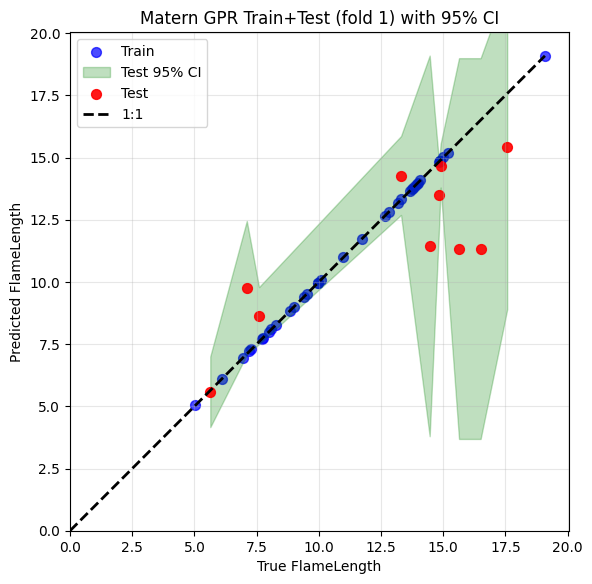

d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


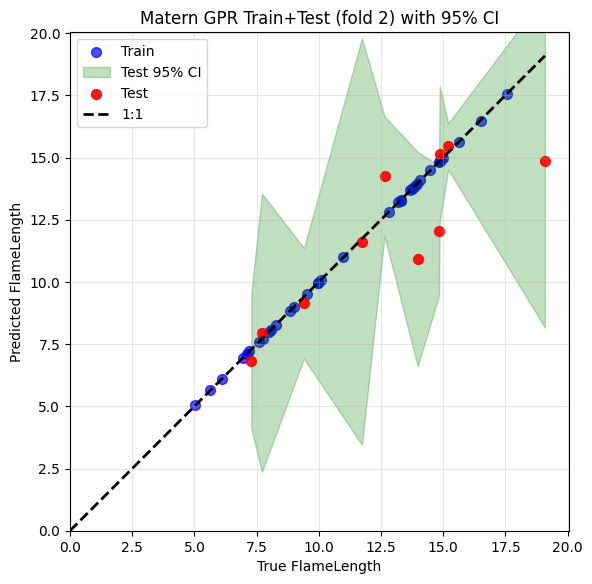

d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


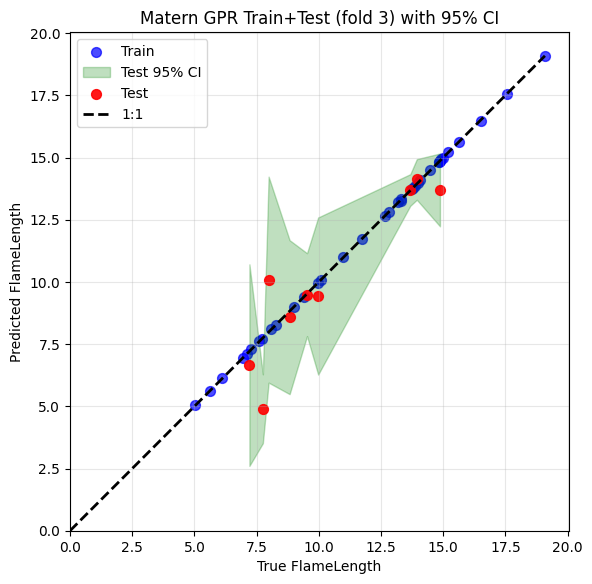

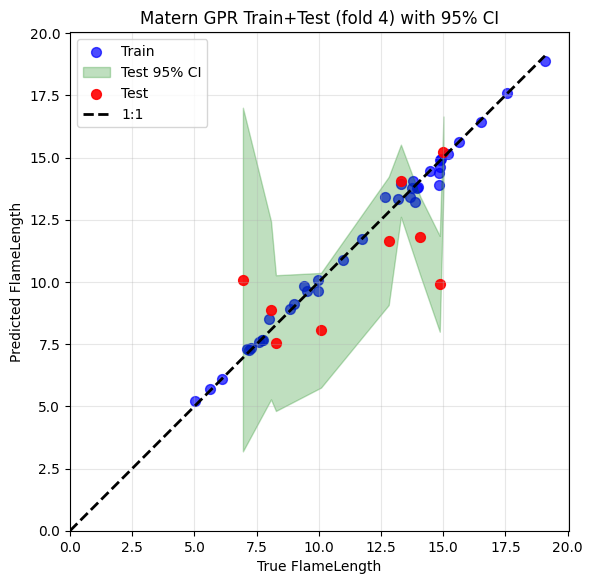

d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


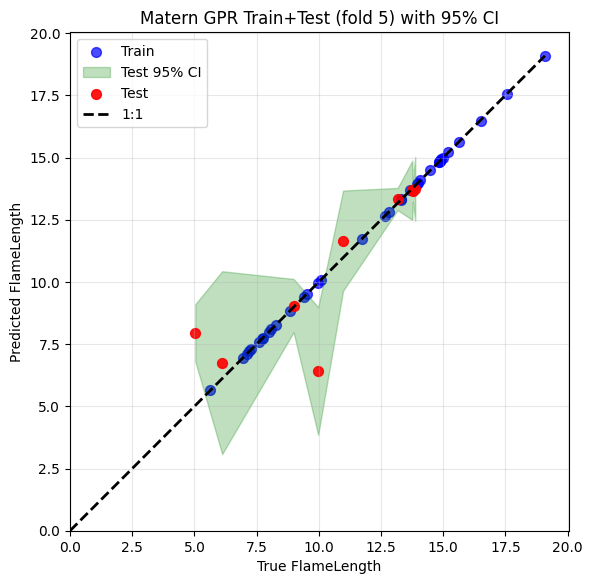

Per-fold metrics (mean ± std):
Train RMSE: 0.07440 ± 0.12960
Test  RMSE: 1.94222 ± 0.54462
Train R2 : 0.99855 ± 0.00319
Test  R2 : 0.64816 ± 0.15158
Test 95% CI coverage: 84.9% ± 6.5%
Avg 95% CI interval width: 1.10624 ± 0.98446
Fitted kernel: 1.18**2 * Matern(length_scale=[1.02, 1.86, 1.48, 10.4, 3.7, 1.74, 7.76e+03], nu=2.5) + WhiteKernel(noise_level=0.001)
Log-marginal-likelihood: -34.04407581102494


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [125]:
# GPR with Matern (ARD) + WhiteKernel; use ARD by passing a vector length_scale
kernel_matern = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e8), nu=2.5
) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e-1))

gpr_matern = GaussianProcessRegressor(
    kernel=kernel_matern, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_matern = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_matern)])

# Cross-validated RMSE (5-fold)
gpr_matern_scores = -cross_val_score(
    pipeline_gpr_matern, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1
)
print(
    f"Matern GPR CV RMSE: mean={gpr_matern_scores.mean():.5f}, std={gpr_matern_scores.std():.5f}"
)
gpr_matern_r2 = cross_val_score(
    pipeline_gpr_matern, X, y, cv=cv, scoring="r2", n_jobs=1
)
print(
    f"Matern GPR CV R2 : mean={gpr_matern_r2.mean():.4f}, std={gpr_matern_r2.std():.4f}"
)

# Per-fold train/test diagnostics
fold_metrics_matern = []
for i, (tr, te) in enumerate(cv.split(X, y), 1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    pipeline_gpr_matern.fit(X_tr, y_tr)

    # use underlying GPR to get std
    X_tr_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X_tr)
    X_te_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X_te)
    y_tr_pred, y_tr_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_tr_scaled, return_std=True
    )
    y_te_pred, y_te_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )

    # per-fold test (OOF) 95% CI coverage
    lower_bound_te = y_te_pred - 1.96 * y_te_std
    upper_bound_te = y_te_pred + 1.96 * y_te_std
    within_ci_te = (y_te.values >= lower_bound_te) & (y_te.values <= upper_bound_te)
    coverage_te_95 = 100 * within_ci_te.sum() / len(y_te)

    fold_metrics_matern.append(
        {
            "fold": i,
            "train_rmse": rmse(y_tr, y_tr_pred),
            "test_rmse": rmse(y_te, y_te_pred),
            "train_r2": r2_score(y_tr, y_tr_pred),
            "test_r2": r2_score(y_te, y_te_pred),
            "test_coverage_95": coverage_te_95,
        }
    )

    # sort for smooth CI plotting
    sort_idx_tr = np.argsort(y_tr.values)
    y_tr_sorted = y_tr.values[sort_idx_tr]
    y_tr_pred_sorted = y_tr_pred[sort_idx_tr]
    y_tr_std_sorted = y_tr_std[sort_idx_tr]

    sort_idx_te = np.argsort(y_te.values)
    y_te_sorted = y_te.values[sort_idx_te]
    y_te_pred_sorted = y_te_pred[sort_idx_te]
    y_te_std_sorted = y_te_std[sort_idx_te]

    # combined train+test plot per fold
    plt.figure(figsize=(6, 6))
    # train CI + points
    plt.scatter(y_tr_sorted, y_tr_pred_sorted, alpha=0.7, s=50, color='blue', label="Train")
    # test CI + points
    plt.fill_between(y_te_sorted,
                     y_te_pred_sorted - 1.96 * y_te_std_sorted,
                     y_te_pred_sorted + 1.96 * y_te_std_sorted,
                     alpha=0.25, color='green', label='Test 95% CI')
    plt.scatter(y_te_sorted, y_te_pred_sorted, alpha=0.9, s=50, color='red', label="Test")

    max_val = max(y_tr_sorted.max(), y_te_sorted.max())
    plt.plot([0, max_val], [0, max_val], "k--", lw=2, label="1:1")
    plt.xlabel("True FlameLength")
    plt.ylabel("Predicted FlameLength")
    plt.xlim(0, max_val * 1.05)
    plt.ylim(0, max_val * 1.05)
    plt.legend()
    plt.title(f"Matern GPR Train+Test (fold {i}) with 95% CI")
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

fold_df_matern = pd.DataFrame(fold_metrics_matern)
print("Per-fold metrics (mean ± std):")
print(
    f"Train RMSE: {fold_df_matern.train_rmse.mean():.5f} ± {fold_df_matern.train_rmse.std():.5f}"
)
print(
    f"Test  RMSE: {fold_df_matern.test_rmse.mean():.5f} ± {fold_df_matern.test_rmse.std():.5f}"
)
print(
    f"Train R2 : {fold_df_matern.train_r2.mean():.5f} ± {fold_df_matern.train_r2.std():.5f}"
)
print(
    f"Test  R2 : {fold_df_matern.test_r2.mean():.5f} ± {fold_df_matern.test_r2.std():.5f}"
)
print(
    f"Test 95% CI coverage: {fold_df_matern.test_coverage_95.mean():.1f}% ± {fold_df_matern.test_coverage_95.std():.1f}%"
)

# Calculate average CI interval width per fold
ci_widths = []
for i, (tr, te) in enumerate(cv.split(X, y)):
    X_te_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X.iloc[te])
    _, y_te_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )
    ci_width = 2 * 1.96 * y_te_std.mean()  # avg interval width (±1.96σ)
    ci_widths.append(ci_width)

print(f"Avg 95% CI interval width: {np.mean(ci_widths):.5f} ± {np.std(ci_widths):.5f}")


# Fit on full data and diagnostics
pipeline_gpr_matern.fit(X, y)
gpr_matern_fitted = pipeline_gpr_matern.named_steps["gpr"]
print("Fitted kernel:", gpr_matern_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_matern_fitted.log_marginal_likelihood_value_)